In [38]:
!pip install torchmetrics optuna psycopg2-binary kagglehub scipy -q

In [39]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import shutil
from scipy.cluster.hierarchy import dendrogram, linkage

In [40]:
os.environ["KAGGLE_API_TOKEN"] = "api"

path = kagglehub.dataset_download("frtgnn/dunnhumby-the-complete-journey")
print("Data is ready at:", path)

Using Colab cache for faster access to the 'dunnhumby-the-complete-journey' dataset.
Data is ready at: /kaggle/input/dunnhumby-the-complete-journey


In [41]:
shutil.copytree(path, "hh_data", dirs_exist_ok=True)

print("Data successfully moved to the visible 'hh_data' folder!")

Data successfully moved to the visible 'hh_data' folder!


##**Data Loading**

In [42]:
df = pd.read_csv("hh_data/transaction_data.csv")

In [43]:
product_df = pd.read_csv("/content/hh_data/product.csv")

In [44]:
df

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2595727,1598,42305362535,711,92130,1,0.99,3228,0.00,1520,102,0.0,0.0
2595728,1598,42305362535,711,114102,1,8.89,3228,0.00,1520,102,0.0,0.0
2595729,1598,42305362535,711,133449,1,6.99,3228,0.00,1520,102,0.0,0.0
2595730,1598,42305362535,711,6923644,1,4.50,3228,-0.49,1520,102,0.0,0.0


In [45]:
df.dtypes

,0
household_key,int64
BASKET_ID,int64
DAY,int64
PRODUCT_ID,int64
QUANTITY,int64
SALES_VALUE,float64
STORE_ID,int64
RETAIL_DISC,float64
TRANS_TIME,int64
WEEK_NO,int64


In [46]:
df.isna().sum()

,0
household_key,0
BASKET_ID,0
DAY,0
PRODUCT_ID,0
QUANTITY,0
SALES_VALUE,0
STORE_ID,0
RETAIL_DISC,0
TRANS_TIME,0
WEEK_NO,0


##**Data Preprocessing**

In [47]:
snapshot_date = df['DAY'].max() + 1
rfm = df.groupby('household_key').agg(
    Recency   = ('DAY',         lambda x: snapshot_date - x.max()),
    Frequency = ('BASKET_ID',   'nunique'),
    Monetary  = ('SALES_VALUE', 'sum')
).reset_index()

In [48]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

##**K-Means Clustering**

In [49]:
results = []
for k in range(2, 10):
    km     = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    results.append({'k': k, 'silhouette': silhouette_score(rfm_scaled, labels), 'inertia': km.inertia_})
    print(f"k={k} → Silhouette: {results[-1]['silhouette']:.3f} | Inertia: {results[-1]['inertia']:.1f}")

results_df = pd.DataFrame(results)
best_k = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
print(f"\nBest k={best_k} with Silhouette Score={results_df['silhouette'].max():.3f}")

k=2 → Silhouette: 0.656 | Inertia: 5747.1
k=3 → Silhouette: 0.574 | Inertia: 3140.8
k=4 → Silhouette: 0.446 | Inertia: 2365.3
k=5 → Silhouette: 0.407 | Inertia: 2021.5
k=6 → Silhouette: 0.440 | Inertia: 1612.8
k=7 → Silhouette: 0.419 | Inertia: 1438.4
k=8 → Silhouette: 0.388 | Inertia: 1207.0
k=9 → Silhouette: 0.374 | Inertia: 1101.4

Best k=2 with Silhouette Score=0.656


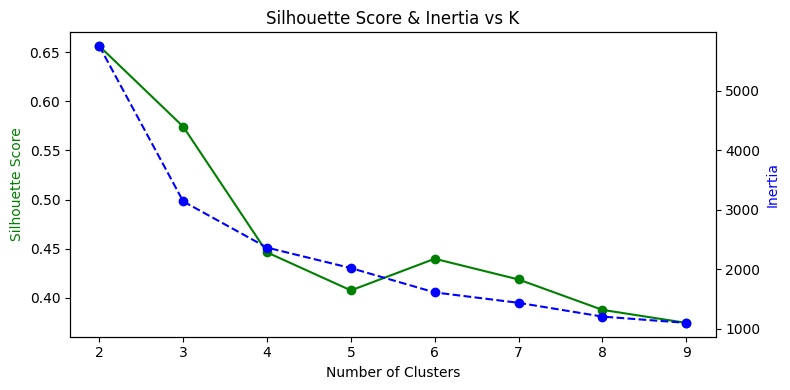

In [50]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(results_df['k'], results_df['silhouette'], 'go-', label='Silhouette')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette Score', color='green')
ax2 = ax1.twinx()
ax2.plot(results_df['k'], results_df['inertia'], 'bo--', label='Inertia')
ax2.set_ylabel('Inertia', color='blue')
plt.title('Silhouette Score & Inertia vs K')
fig.tight_layout()
plt.show()

In [51]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

In [52]:
segment_names = {0: 'Active Shoppers', 1: 'Churned'}
rfm['Segment_Label'] = rfm['Segment'].map(segment_names)

print(rfm.groupby('Segment_Label')[['Recency', 'Frequency', 'Monetary']].mean().round(1))
print("\nSegment sizes:\n", rfm['Segment_Label'].value_counts())

                 Recency  Frequency  Monetary
Segment_Label                                
Active Shoppers     16.6      113.9    3323.3
Churned            285.5       26.2     626.0

Segment sizes:
 Segment_Label
Active Shoppers    2407
Churned              93
Name: count, dtype: int64


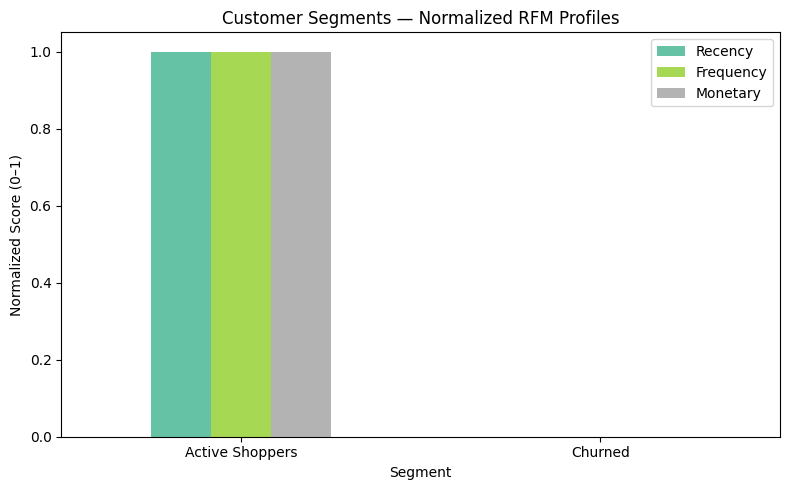

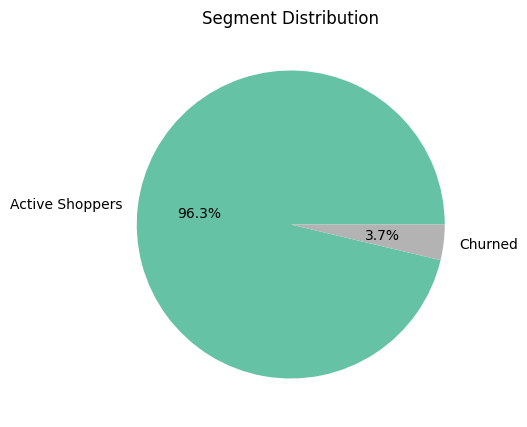

In [53]:
rfm_means = rfm.groupby('Segment_Label')[['Recency', 'Frequency', 'Monetary']].mean()
rfm_means['Recency'] = 1 / rfm_means['Recency']  # invert: lower recency = more recent = better
rfm_norm = (rfm_means - rfm_means.min()) / (rfm_means.max() - rfm_means.min())

rfm_norm.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Customer Segments — Normalized RFM Profiles')
plt.xlabel('Segment')
plt.ylabel('Normalized Score (0–1)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rfm['Segment_Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5, 5), colormap='Set2')
plt.title('Segment Distribution')
plt.ylabel('')
plt.show()

In [54]:
top_cats = df.merge(rfm[['household_key','Segment_Label']], on='household_key')
top_cats = top_cats.merge(product_df[['PRODUCT_ID','DEPARTMENT']], on='PRODUCT_ID')
print(top_cats.groupby(['Segment_Label','DEPARTMENT'])['SALES_VALUE'].sum()
      .groupby(level=0, group_keys=False).nlargest(3))

Segment_Label    DEPARTMENT
Active Shoppers  GROCERY       4063329.46
                 DRUG GM       1047627.85
                 PRODUCE        553411.17
Churned          GROCERY         30484.68
                 DRUG GM          7730.18
                 PRODUCE          4040.94
Name: SALES_VALUE, dtype: float64


=== Top Products by Segment ===
  Segment_Label         COMMODITY_DESC  Total Spend
Active Shoppers      COUPON/MISC ITEMS    635328.16
Active Shoppers            SOFT DRINKS    324309.97
Active Shoppers                   BEEF    310016.83
Active Shoppers    FLUID MILK PRODUCTS    203819.28
Active Shoppers                 CHEESE    188105.08
Active Shoppers FRZN MEAT/MEAT DINNERS    159020.77
Active Shoppers             BAG SNACKS    147335.02
Active Shoppers             BEERS/ALES    146427.35
Active Shoppers BAKED BREAD/BUNS/ROLLS    144898.73
Active Shoppers           FROZEN PIZZA    144784.23
        Churned      COUPON/MISC ITEMS      4550.40
        Churned            SOFT DRINKS      3337.33
        Churned                   BEEF      2086.39
        Churned    FLUID MILK PRODUCTS      1536.77
        Churned FRZN MEAT/MEAT DINNERS      1496.40
        Churned                 CHEESE      1423.10
        Churned           FROZEN PIZZA      1253.02
        Churned             BAG 

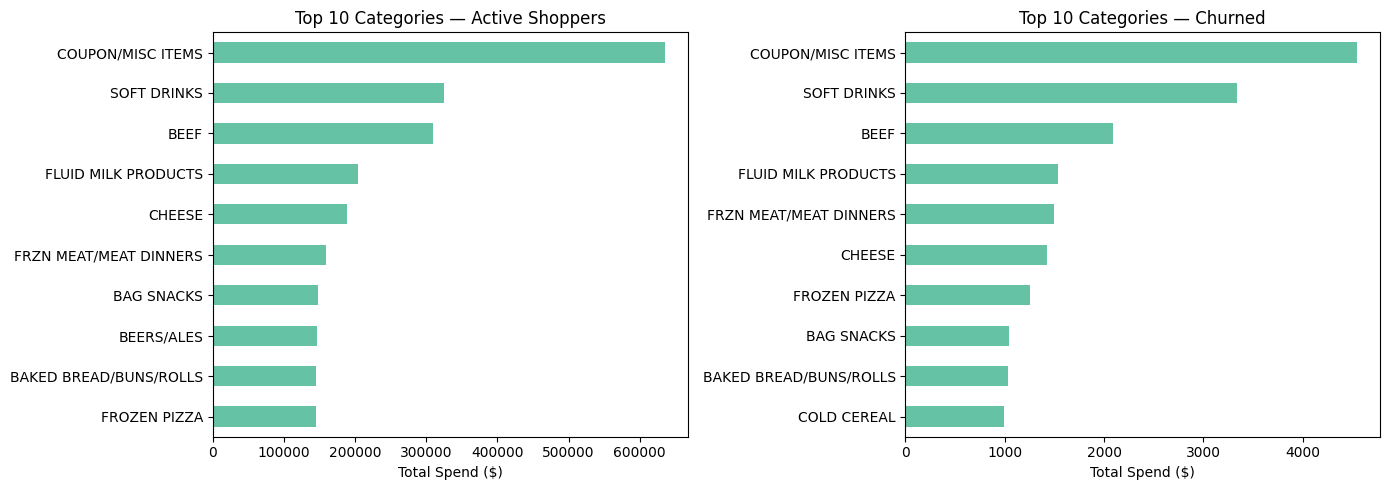

In [55]:
# Top 10 products for each segment
reco = df.merge(rfm[['household_key','Segment_Label']], on='household_key')
reco = reco.merge(product_df[['PRODUCT_ID','COMMODITY_DESC','DEPARTMENT']], on='PRODUCT_ID')

top_products = (reco.groupby(['Segment_Label','COMMODITY_DESC'])['SALES_VALUE']
                .sum()
                .groupby(level=0, group_keys=False).nlargest(10)
                .reset_index()
                .rename(columns={'SALES_VALUE': 'Total Spend'}))

print("=== Top Products by Segment ===")
print(top_products.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (seg, grp) in zip(axes, top_products.groupby('Segment_Label')):
    grp.sort_values('Total Spend').plot(
        kind='barh', x='COMMODITY_DESC', y='Total Spend',
        ax=ax, colormap='Set2', legend=False
    )
    ax.set_title(f'Top 10 Categories — {seg}')
    ax.set_xlabel('Total Spend ($)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

##**DBSCAN**

In [56]:
db = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Label'] = db.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Label'])) - (1 if -1 in rfm['DBSCAN_Label'].values else 0)
n_noise    = (rfm['DBSCAN_Label'] == -1).sum()

print(f"DBSCAN → Clusters: {n_clusters} | Noise points: {n_noise}")
print(rfm['DBSCAN_Label'].value_counts())

DBSCAN → Clusters: 3 | Noise points: 55
DBSCAN_Label
 0    2431
-1      55
 2       8
 1       6
Name: count, dtype: int64


In [57]:
# Silhouette only on non-noise points
mask = rfm['DBSCAN_Label'] != -1
db_score = silhouette_score(rfm_scaled[mask], rfm['DBSCAN_Label'][mask])
print(f"DBSCAN Silhouette Score (excl. noise): {db_score:.3f}")

DBSCAN Silhouette Score (excl. noise): 0.758


In [58]:
print(rfm.groupby('DBSCAN_Label')[['Recency', 'Frequency', 'Monetary']].mean().round(1))
print("\nSegment sizes:\n", rfm['DBSCAN_Label'].value_counts().sort_index())

              Recency  Frequency  Monetary
DBSCAN_Label                              
-1               83.5      475.9   10303.6
 0               22.3      102.9    3080.4
 1              425.7        7.5     281.3
 2              632.8        2.0      73.3

Segment sizes:
 DBSCAN_Label
-1      55
 0    2431
 1       6
 2       8
Name: count, dtype: int64


In [59]:
rfm['Segment_Label'] = rfm['DBSCAN_Label'].map({
    -1: 'VIP',
    0:  'Active Shoppers',
    1:  'Churned',
    2:  'Churned'
})

print(rfm.groupby('Segment_Label')[['Recency','Frequency','Monetary']].mean().round(1))
print("\nSegment sizes:\n", rfm['Segment_Label'].value_counts())

                 Recency  Frequency  Monetary
Segment_Label                                
Active Shoppers     22.3      102.9    3080.4
Churned            544.0        4.4     162.5
VIP                 83.5      475.9   10303.6

Segment sizes:
 Segment_Label
Active Shoppers    2431
VIP                  55
Churned              14
Name: count, dtype: int64


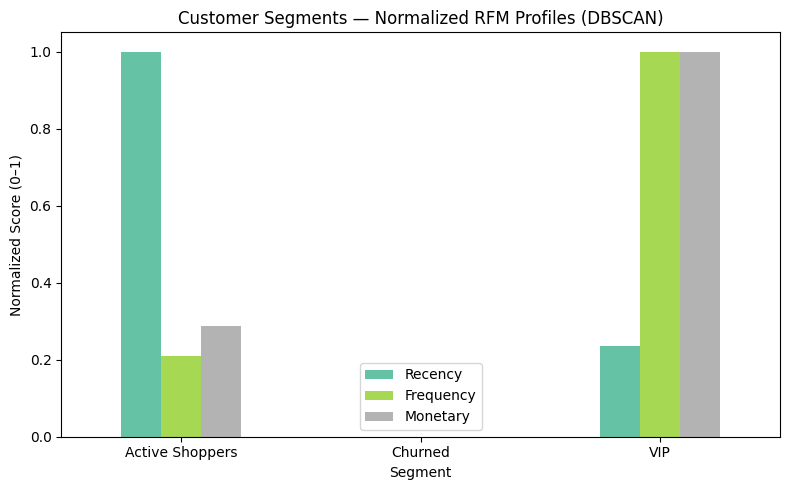

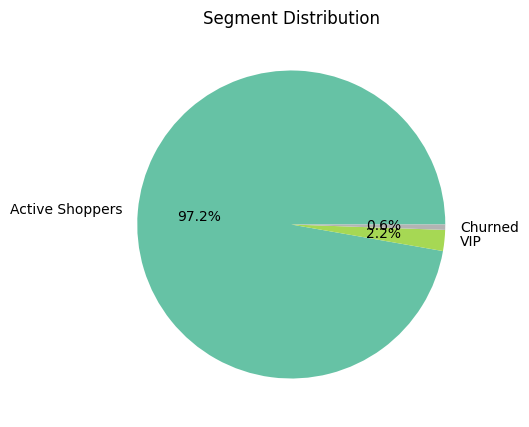

In [60]:
rfm_means = rfm.groupby('Segment_Label')[['Recency','Frequency','Monetary']].mean()
rfm_means['Recency'] = 1 / rfm_means['Recency']  # invert: lower = more recent = better
rfm_norm  = (rfm_means - rfm_means.min()) / (rfm_means.max() - rfm_means.min())

rfm_norm.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Customer Segments — Normalized RFM Profiles (DBSCAN)')
plt.xlabel('Segment')
plt.ylabel('Normalized Score (0–1)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rfm['Segment_Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5), colormap='Set2')
plt.title('Segment Distribution')
plt.ylabel('')
plt.show()


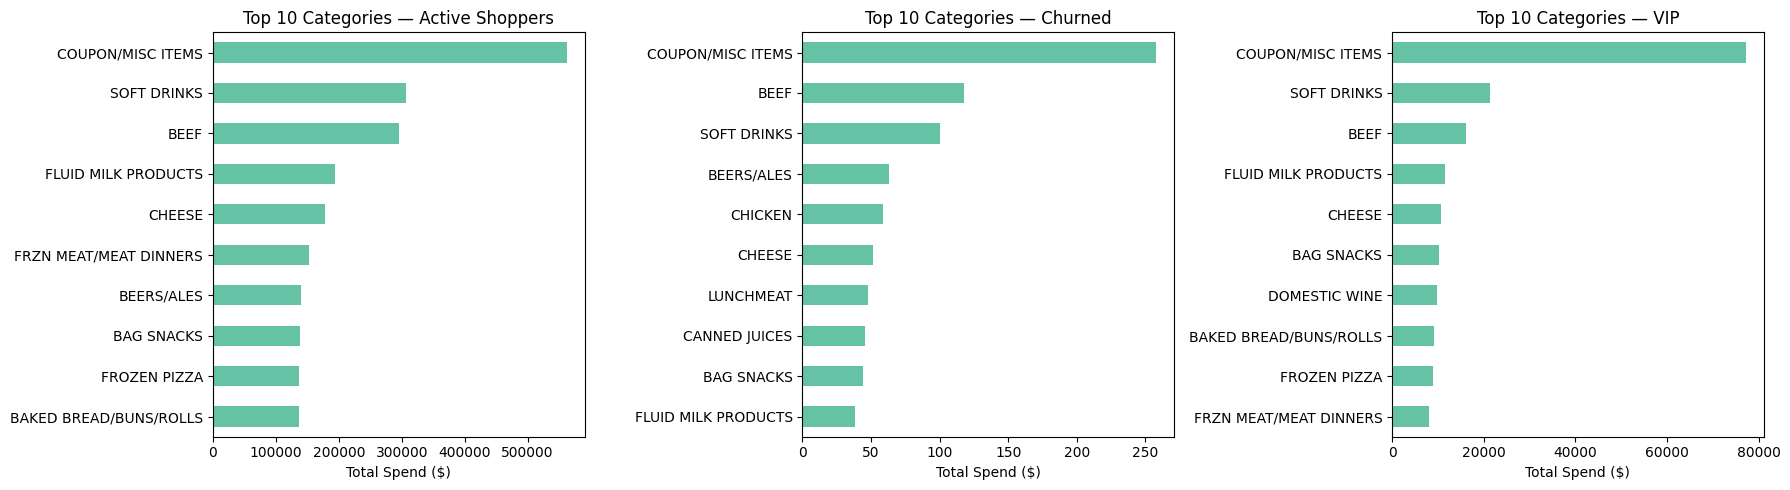

In [61]:
reco = df.merge(rfm[['household_key','Segment_Label']], on='household_key')
reco = reco.merge(product_df[['PRODUCT_ID','COMMODITY_DESC']], on='PRODUCT_ID')

top_products = (reco.groupby(['Segment_Label','COMMODITY_DESC'])['SALES_VALUE']
                .sum()
                .groupby(level=0, group_keys=False).nlargest(10)
                .reset_index()
                .rename(columns={'SALES_VALUE': 'Total Spend'}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (seg, grp) in zip(axes, top_products.groupby('Segment_Label')):
    grp.sort_values('Total Spend').plot(
        kind='barh', x='COMMODITY_DESC', y='Total Spend',
        ax=ax, colormap='Set2', legend=False
    )
    ax.set_title(f'Top 10 Categories — {seg}')
    ax.set_xlabel('Total Spend ($)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

##**Hierarchical Clustering**

In [62]:
results_hc = []
for k in range(2, 10):
    hc     = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(rfm_scaled)
    score  = silhouette_score(rfm_scaled, labels)
    results_hc.append({'k': k, 'silhouette': score})
    print(f"k={k} → Silhouette: {score:.3f}")

results_hc_df = pd.DataFrame(results_hc)
best_hc_k     = int(results_hc_df.loc[results_hc_df['silhouette'].idxmax(), 'k'])
best_hc_score = results_hc_df['silhouette'].max()
print(f"\nBest k={best_hc_k} with Silhouette Score={best_hc_score:.3f}")

# Fit final model with best k
hc = AgglomerativeClustering(n_clusters=best_hc_k)
rfm['HC_Label'] = hc.fit_predict(rfm_scaled)
print(rfm.groupby('HC_Label')[['Recency','Frequency','Monetary']].mean().round(1))
print("\nSegment sizes:\n", rfm['HC_Label'].value_counts().sort_index())

k=2 → Silhouette: 0.522
k=3 → Silhouette: 0.545
k=4 → Silhouette: 0.462
k=5 → Silhouette: 0.463
k=6 → Silhouette: 0.333
k=7 → Silhouette: 0.339
k=8 → Silhouette: 0.341
k=9 → Silhouette: 0.337

Best k=3 with Silhouette Score=0.545
          Recency  Frequency  Monetary
HC_Label                              
0             4.8      275.2    8220.1
1           212.7       33.9     875.6
2            15.8       73.4    2095.2

Segment sizes:
 HC_Label
0     493
1     164
2    1843
Name: count, dtype: int64


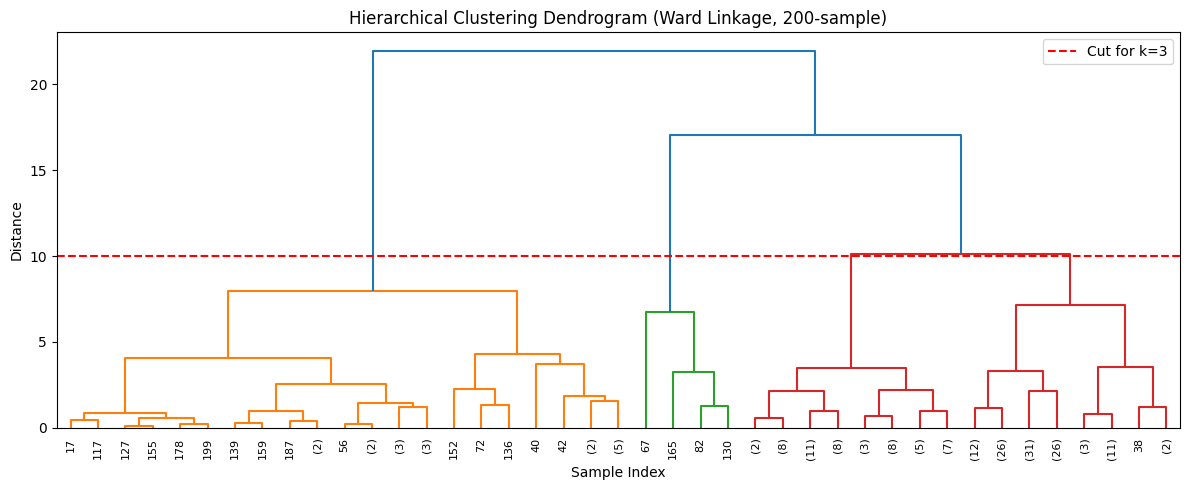

In [63]:
sample_idx = np.random.choice(len(rfm_scaled), 200, replace=False)
Z = linkage(rfm_scaled[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, 200-sample)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', label='Cut for k=3')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
rfm['Segment'].unique()

array([0, 1], dtype=int32)

##**Customers Labeling**

In [78]:
print("--- KMeans Original Cluster Means ---")
print(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

print("\n--- DBSCAN Original Cluster Means ---")
print(rfm.groupby('DBSCAN_Label')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

print("\n--- Hierarchical Original Cluster Means ---")
print(rfm.groupby('HC_Label')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

--- KMeans Original Cluster Means ---
         Recency  Frequency  Monetary
Segment                              
0           16.6      113.9    3323.3
1          285.5       26.2     626.0

--- DBSCAN Original Cluster Means ---
              Recency  Frequency  Monetary
DBSCAN_Label                              
-1               83.5      475.9   10303.6
 0               22.3      102.9    3080.4
 1              425.7        7.5     281.3
 2              632.8        2.0      73.3

--- Hierarchical Original Cluster Means ---
          Recency  Frequency  Monetary
HC_Label                              
0             4.8      275.2    8220.1
1           212.7       33.9     875.6
2            15.8       73.4    2095.2


In [79]:
# 0 --> VIP (High Frequency/Monetary, Low Recency)
# 1 --> Active Shoppers (Average across the board)
# 2 --> Churned (High Recency, Low Frequency/Monetary)

# Map KMeans Segments
rfm['KMeans_Unified'] = rfm['Segment'].map({
    0: 1,
    1: 2
})

# DBSCAN
rfm['DBSCAN_Unified'] = rfm['DBSCAN_Label'].map({
    -1: 0,
     0: 1,
     1: 2,
     2: 2
})

# hierarchical Segments
rfm['HC_Unified'] = rfm['HC_Label'].map({
    0: 0,
    2: 1,
    1: 2
})

In [81]:
columns_to_keep = ['household_key', 'Recency', 'Frequency', 'Monetary', 'KMeans_Unified', 'DBSCAN_Unified', 'HC_Unified']
rfm[columns_to_keep].to_csv('All_Customer_Segments_Combined.csv')
print("Combined and unified segments exported successfully!")

Combined and unified segments exported successfully!


In [82]:
rfm[columns_to_keep]

,household_key,Recency,Frequency,Monetary,KMeans_Unified,DBSCAN_Unified,HC_Unified
0,1,6,86,4330.16,1,1,1
1,2,44,45,1954.34,1,1,1
2,3,9,47,2653.21,1,1,1
3,4,85,30,1200.11,1,1,1
4,5,9,40,779.06,1,1,1
...,...,...,...,...,...,...,...
2495,2496,29,63,4339.66,1,1,1
2496,2497,12,221,7111.98,1,1,0
2497,2498,2,172,2601.60,1,1,1
2498,2499,3,90,3394.07,1,1,1


In [84]:
rfm[columns_to_keep].isna().sum()

,0
household_key,0
Recency,0
Frequency,0
Monetary,0
KMeans_Unified,0
DBSCAN_Unified,0
HC_Unified,0
